In [1]:
import sys
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# 1. Chỉ đường cho Python ra thư mục gốc TTCS
root_path = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root_path not in sys.path:
    sys.path.append(root_path)

# 2. Import các hàm từ src của nhóm mình
from src.utils import evaluate_model
from src.data_loader import load_and_preprocess

print("--- Đang nạp mô hình và dữ liệu CNN ---")

# 3. Tải lại mô hình và Label Encoder (Nhớ dấu ../)
model = load_model('../models/best_cnn_model.h5', compile=False)
le = joblib.load('../models/label_encoder_cnn.pkl')

# 4. Tải dữ liệu Test và lấy luôn MASTER ENCODER (le_final) chứa CHỮ
_, X_test_s, _, y_test, le_final, _ = load_and_preprocess('../data/Dataset-Unicauca-Version2-87Atts.csv')
X_test_3d = np.expand_dims(X_test_s, axis=2)

# Lấy danh sách tên App CHUẨN BẰNG CHỮ từ le_final
app_names_text = [str(name) for name in le_final.classes_]

# 5. Dự đoán
print("--- Đang xử lý dự đoán... ---")
y_pred = model.predict(X_test_3d)
y_pred_classes = np.argmax(y_pred, axis=1)

# Ép kiểu y_test về số nguyên
y_test_int = y_test.astype(int)

# Lọc bỏ các nhãn nằm ngoài danh sách (nếu có)
valid_mask = y_test_int < len(app_names_text)
y_test_filtered = y_test_int[valid_mask]
y_pred_filtered = y_pred_classes[valid_mask]

print("\n--- KẾT QUẢ F1-SCORE CNN ---")
from sklearn.metrics import classification_report

# Chạy lệnh này in ra số cho đồng bộ với Confusion Matrix ở dưới
report = classification_report(
    y_test_filtered, 
    y_pred_filtered, 
    zero_division=0
)
print(report)

--- Đang nạp mô hình và dữ liệu CNN ---
--- Đang xử lý dự đoán... ---
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step

--- KẾT QUẢ F1-SCORE CNN ---
              precision    recall  f1-score   support

           0       0.81      0.41      0.54      1400
           1       0.34      0.41      0.37       139
           2       0.05      0.22      0.08        23
           3       0.02      0.11      0.03        19
           7       0.00      0.00      0.00         1
           8       0.68      0.39      0.50       264
           9       0.84      0.86      0.85       145
          10       0.00      0.00      0.00         1
          11       0.45      0.95      0.62        21
          12       0.85      0.71      0.77       431
          13       0.02      0.43      0.04         7
          14       0.02      0.14      0.03        22
          16       0.87      0.71      0.78       485
          17       0.00      0.00      0.00         1
          18       0.00      0.00      0.00   

In [ ]:
import sys
import os
import joblib
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report

# 1. Xử lý đường dẫn hệ thống (Cực kỳ quan trọng trong Notebook)
# Lấy thư mục hiện tại của Notebook
current_dir = os.getcwd()

root_path = os.path.abspath(os.path.join(current_dir, '..')) 

if root_path not in sys.path:
    sys.path.append(root_path)

from src.data_loader import load_and_preprocess

print("--- Đang nạp mô hình và dữ liệu LSTM ---")

# 2. Cấu hình đường dẫn file (Dùng biến để dễ sửa)
MODEL_PATH = os.path.join(root_path, 'models', 'best_lstm_model.h5')
LE_PATH = os.path.join(root_path, 'models', 'label_encoder_lstm.pkl')
DATA_PATH = os.path.join(root_path, 'data', 'Dataset-Unicauca-Version2-87Atts.csv')

# 3. Tải mô hình và Label Encoder
# Thêm compile=False để tránh lỗi Custom Loss (Focal Loss)
model_lstm = load_model(MODEL_PATH, compile=False)

if os.path.exists(LE_PATH):
    le = joblib.load(LE_PATH)
    print(f"✅ Đã nạp thành công: {os.path.basename(LE_PATH)}")
else:
    # Cảnh báo mạnh hơn nếu không tìm thấy file pkl đúng của LSTM
    print("⚠️ CẢNH BÁO: Không tìm thấy label_encoder_lstm.pkl!")
    le_cnn_path = os.path.join(root_path, 'models', 'label_encoder_cnn.pkl')
    le = joblib.load(le_cnn_path)
    print("Sử dụng tạm label_encoder_cnn.pkl ")

# 4. Tải và Reshape dữ liệu

_, X_test_s, _, y_test, _, _ = load_and_preprocess(DATA_PATH)
X_test_3d = np.expand_dims(X_test_s, axis=2)

print(f"--- Đang xử lý dự đoán cho {len(X_test_3d)} mẫu... ---")
y_pred = model_lstm.predict(X_test_3d, batch_size=128) # Thêm batch_size để chạy nhanh hơn
y_pred_classes = np.argmax(y_pred, axis=1)

# 5. Xử lý lọc nhãn và tạo báo cáo
valid_mask = np.isin(y_test, le.classes_)
y_test_filtered = y_test[valid_mask]
y_pred_filtered = y_pred_classes[valid_mask]

y_test_fixed = le.transform(y_test_filtered)
actual_labels = np.unique(y_test_fixed) 
actual_names = [str(le.classes_[i]) for i in actual_labels]

print("\n--- KẾT QUẢ F1-SCORE LSTM (Nâng cao với Focal Loss) ---")
report = classification_report(y_test_fixed, y_pred_filtered, 
                               labels=actual_labels, 
                               target_names=actual_names)
print(report)

--- Đang nạp mô hình và dữ liệu LSTM ---
✅ Đã nạp thành công: label_encoder_lstm.pkl
--- Đang xử lý dự đoán cho 60000 mẫu... ---
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 50ms/step

--- KẾT QUẢ F1-SCORE LSTM (Nâng cao với Focal Loss) ---
              precision    recall  f1-score   support

           0       0.75      0.37      0.49      1400
           1       0.26      0.39      0.31       139
           2       0.04      0.17      0.07        23
           3       0.01      0.05      0.02        19
           7       0.00      0.00      0.00         1
           8       0.72      0.37      0.49       264
           9       0.83      0.83      0.83       145
          10       0.00      0.00      0.00         1
          11       0.46      0.90      0.61        21
          12       0.88      0.68      0.77       431
          13       0.05      0.43      0.09         7
          14       0.01      0.05      0.01        22
          16       0.90      0.66      0.76       485
          17  

c:\Users\ADMIN\OneDrive\Máy tính\TTCS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ADMIN\OneDrive\Máy tính\TTCS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ADMIN\OneDrive\Máy tính\TTCS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

In [2]:
import sys
import os
import joblib
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Trỏ đường dẫn về thư mục gốc TTCS
root_path = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root_path not in sys.path:
    sys.path.append(root_path)

from src.data_loader import load_and_preprocess

print("--- [Notebook] Nạp mô hình XGBoost 67% ---")

# 2. Tải mô hình và 2 bộ Encoders
model_xgb = XGBClassifier()
model_xgb.load_model(os.path.join(root_path, 'models', 'best_xgboost_model.json'))

le_final = joblib.load(os.path.join(root_path, 'models', 'label_encoder_xgboost.pkl'))
le_xg = joblib.load(os.path.join(root_path, 'models', 'label_encoder_xgboost_internal.pkl'))

# 3. Tải và xử lý tập Test
_, X_test_s, _, y_test, _, _ = load_and_preprocess(os.path.join(root_path, 'data', 'Dataset-Unicauca-Version2-87Atts.csv'))

# Ép phẳng dữ liệu cho XGBoost (Chuyển từ 3D của CNN/LSTM về 2D)
X_test_2d = X_test_s.reshape(X_test_s.shape[0], -1)

print("--- Đang dự đoán... ---")
y_pred_encoded = model_xgb.predict(X_test_2d)

# 4. LỌC VÀ ĐỒNG BỘ NHÃN CHUẨN XÁC
y_test_cast = y_test.astype(int) 

# Chỉ lấy những nhãn mà XGBoost thực sự được học (tránh lỗi nhãn lạ)
mask = np.isin(y_test_cast, le_xg.classes_)
y_test_filtered = y_test_cast[mask]
y_pred_filtered = y_pred_encoded[mask]

# Chuyển nhãn thật về hệ 0, 1, 2...
y_test_encoded = le_xg.transform(y_test_filtered)

# Lấy danh sách tên App chuẩn (Ánh xạ từ le_xg sang le_final)
actual_names = [str(le_final.classes_[int(c)]) for c in le_xg.classes_]

# 5. IN KẾT QUẢ
acc = accuracy_score(y_test_encoded, y_pred_filtered)
print(f"\n🔥 ACCURACY THỰC TẾ CỦA XGBOOST: {acc * 100:.2f}%\n")

print("--- BẢNG F1-SCORE XGBOOST ---")
report = classification_report(
    y_test_encoded, 
    y_pred_filtered, 
    labels=np.arange(len(actual_names)),
    target_names=actual_names,
    zero_division=0
)
print(report)

--- [Notebook] Nạp mô hình XGBoost 67% ---
--- Đang dự đoán... ---

🔥 ACCURACY THỰC TẾ CỦA XGBOOST: 66.97%

--- BẢNG F1-SCORE XGBOOST ---
                precision    recall  f1-score   support

        AMAZON       0.79      0.57      0.66      1400
         APPLE       0.48      0.49      0.49       139
  APPLE_ICLOUD       0.25      0.26      0.26        23
  APPLE_ITUNES       0.11      0.11      0.11        19
    CLOUDFLARE       0.68      0.53      0.60       264
 CONTENT_FLASH       0.90      0.90      0.90       145
           DNS       0.61      0.90      0.73        21
       DROPBOX       0.92      0.75      0.83       431
      EASYTAXI       0.21      0.43      0.29         7
          EBAY       0.00      0.00      0.00        22
      FACEBOOK       0.87      0.79      0.83       485
      FTP_DATA       0.00      0.00      0.00         5
         GMAIL       0.49      0.16      0.25       702
        GOOGLE       0.80      0.81      0.81     16112
   GOOGLE_MAPS       

In [2]:
import sys
import os
import pandas as pd

# --- ĐOẠN NÀY LÀ ĐỂ CHỈ ĐƯỜNG CHO PYTHON THẤY THƯ MỤC 'src' ---
root_path = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root_path not in sys.path:
    sys.path.append(root_path)
# -----------------------------------------------------------

from src.data_loader import load_and_preprocess

print("Đang nạp và gọt dũa dữ liệu...")
# 1. Gọi hàm chuẩn bị dữ liệu của nhóm ông
_, X_test_s, _, _, _, _ = load_and_preprocess('../data/Dataset-Unicauca-Version2-87Atts.csv')

# 2. Cắt lấy đúng 20 dòng đầu tiên của tập Test (đã được chuẩn hóa thành 50 cột số)
df_demo = pd.DataFrame(X_test_s[:20])

# 3. Xuất ra một file CSV siêu nhẹ (chỉ vài KB)
df_demo.to_csv('../data/demo_test_web.csv', index=False)
print("✅ Đã tạo xong! Ông ra thư mục 'data' lấy file 'demo_test_web.csv' nhé.")

Đang nạp và gọt dũa dữ liệu...
✅ Đã tạo xong! Ông ra thư mục 'data' lấy file 'demo_test_web.csv' nhé.


⏳ Đang nạp dữ liệu (bước này hơi mất thời gian xíu, ông ráng đợi nhé)...
⏳ Đang nạp mô hình và tính toán Ma trận nhầm lẫn...
✅ Đã lưu ảnh thành công vào thư mục models/confusion_matrix_top10.png


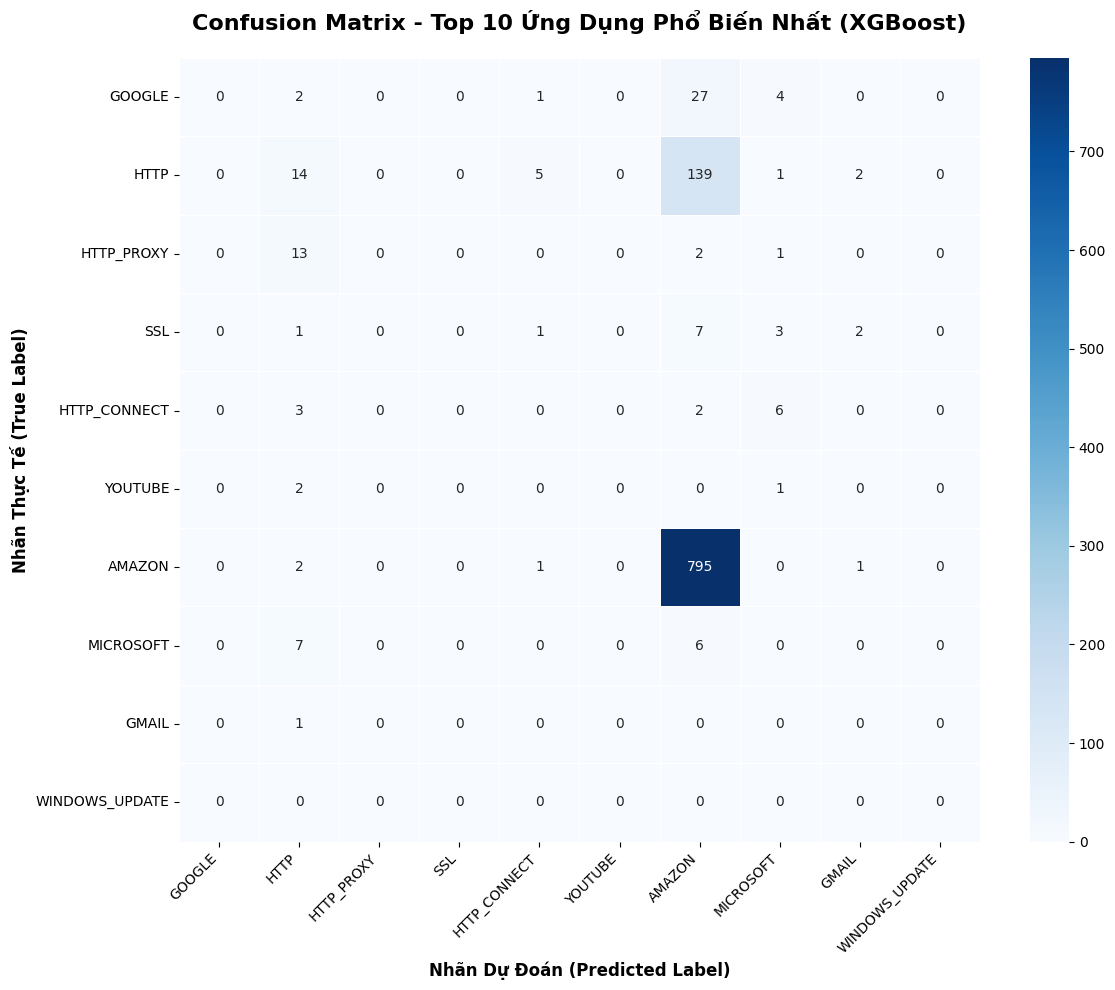

In [ ]:
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
import joblib

# Chỉ đường cho thư mục src
root_path = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root_path not in sys.path:
    sys.path.append(root_path)

from src.data_loader import load_and_preprocess

print("⏳ Đang nạp dữ liệu ...")
# Tải dữ liệu để tạo X_test_s và y_test
_, X_test_s, _, y_test, _, _ = load_and_preprocess('../data/Dataset-Unicauca-Version2-87Atts.csv')

print("⏳ Đang nạp mô hình và tính toán Ma trận nhầm lẫn...")
# Khởi tạo và nạp trọng số XGBoost
model = XGBClassifier()
model.load_model('../models/best_xgboost_model.json')

# Nạp bộ dịch nhãn để lấy tên chữ của ứng dụng
le_final = joblib.load('../models/label_encoder_xgboost.pkl')

# 1. Chạy dự đoán bằng XGBoost 
y_pred_xgb = model.predict(X_test_s) 

# 2. Tìm ra Top 10 ứng dụng xuất hiện nhiều nhất trong tập Test
top_10_labels = pd.Series(y_test).value_counts().head(10).index.tolist()

# Lấy tên bằng CHỮ của 10 ứng dụng này
top_10_names = [str(le_final.classes_[int(i)]) for i in top_10_labels]

# 3. Tạo Ma trận nhầm lẫn CHỈ cho 10 ứng dụng này
cm_top10 = confusion_matrix(y_test, y_pred_xgb, labels=top_10_labels)

# 4. Vẽ đồ thị (Heatmap) cực xịn
plt.figure(figsize=(12, 10))
sns.heatmap(cm_top10, annot=True, fmt='d', cmap='Blues',
            xticklabels=top_10_names, 
            yticklabels=top_10_names,
            linewidths=.5)

plt.title('Confusion Matrix - Top 10 Ứng Dụng Phổ Biến Nhất (XGBoost)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Nhãn Thực Tế (True Label)', fontsize=12, fontweight='bold')
plt.xlabel('Nhãn Dự Đoán (Predicted Label)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')

# Lưu ảnh 
plt.tight_layout()
plt.savefig('../models/confusion_matrix_top10.png', dpi=300)
print("✅ Đã lưu ảnh thành công vào thư mục models/confusion_matrix_top10.png")

plt.show()

⏳ Đang nạp mô hình CNN và LSTM...
⏳ Đang định dạng lại dữ liệu thành 3D (Samples, Features, 1)...
⏳ Đang chạy dự đoán (sẽ mất khoảng 1-2 phút tùy máy)...
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step


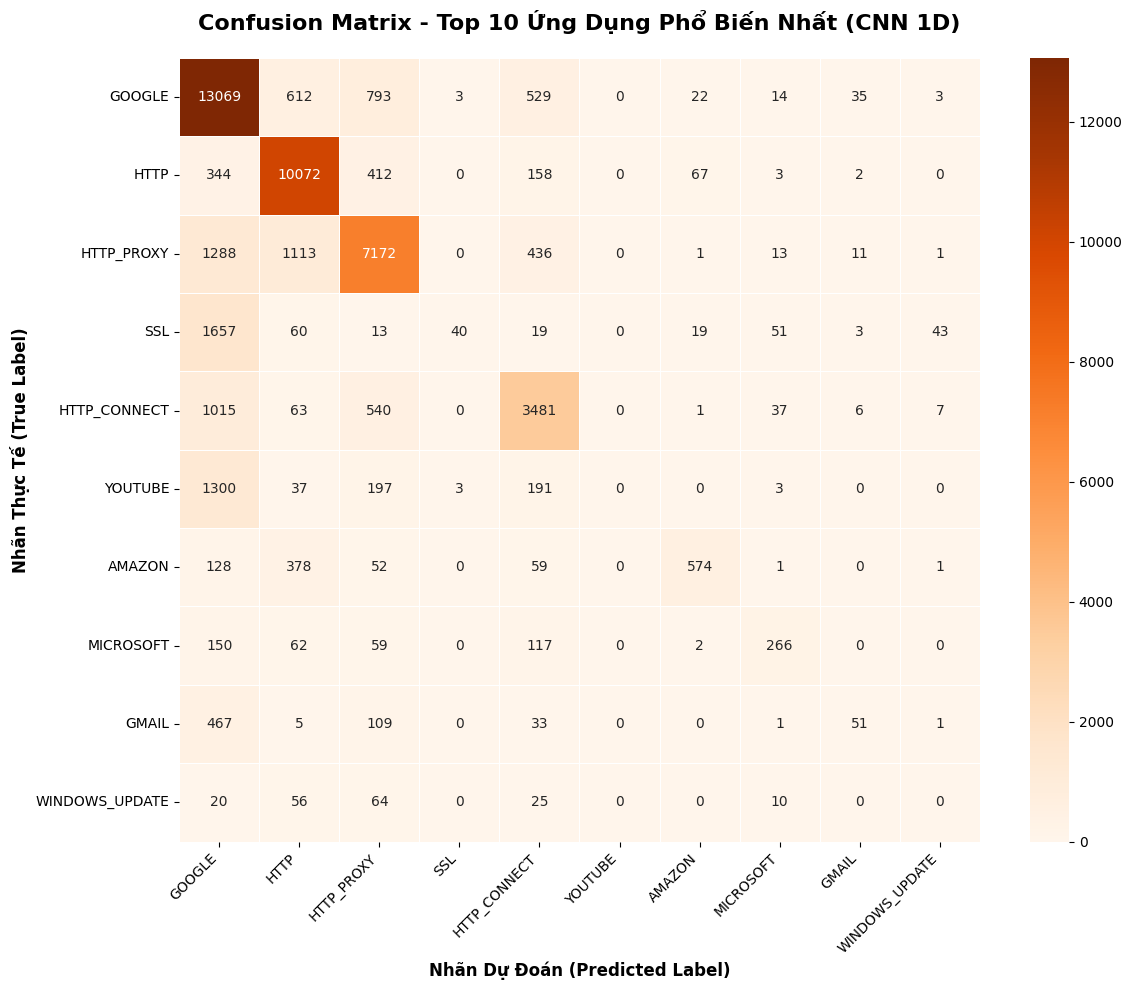

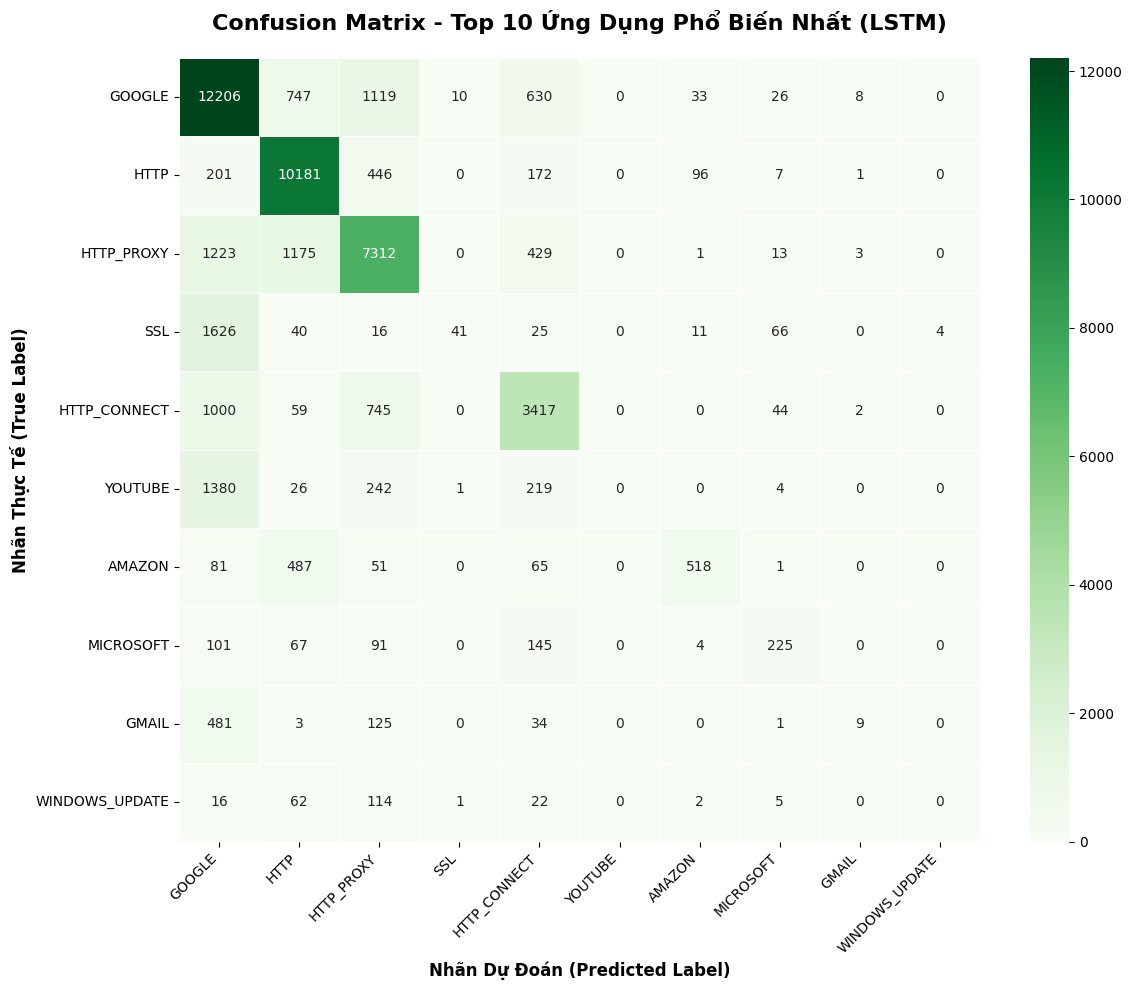

✅ Đã xuất thành công 2 ảnh vào thư mục models/ !


In [ ]:
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd

print("⏳ Đang nạp mô hình CNN và LSTM...")
# Nạp model và bỏ qua cấu trúc compile để tránh lỗi
model_cnn = load_model('../models/best_cnn_model.h5', compile=False)
model_lstm = load_model('../models/best_lstm_model.h5', compile=False)

print("⏳ Đang định dạng lại dữ liệu thành 3D (Samples, Features, 1)...")
X_test_3d = np.expand_dims(X_test_s, axis=2)

print("⏳ Đang chạy dự đoán ...")
# Mạng Nơ-ron trả về xác suất, nên phải dùng argmax để lấy ra nhãn dự đoán cuối cùng
y_pred_cnn = np.argmax(model_cnn.predict(X_test_3d), axis=1)
y_pred_lstm = np.argmax(model_lstm.predict(X_test_3d), axis=1)

# Lấy lại Top 10 nhãn phổ biến đã tính ở ô trước
top_10_labels = pd.Series(y_test).value_counts().head(10).index.tolist()
top_10_names = [str(le_final.classes_[int(i)]) for i in top_10_labels]

# --- VẼ MA TRẬN CHO CNN ---
cm_cnn = confusion_matrix(y_test, y_pred_cnn, labels=top_10_labels)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=top_10_names, yticklabels=top_10_names, linewidths=.5)
plt.title('Confusion Matrix - Top 10 Ứng Dụng Phổ Biến Nhất (CNN 1D)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Nhãn Thực Tế (True Label)', fontsize=12, fontweight='bold')
plt.xlabel('Nhãn Dự Đoán (Predicted Label)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../models/confusion_matrix_cnn.png', dpi=300)
plt.show()

# --- VẼ MA TRẬN CHO LSTM ---
cm_lstm = confusion_matrix(y_test, y_pred_lstm, labels=top_10_labels)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=top_10_names, yticklabels=top_10_names, linewidths=.5)
plt.title('Confusion Matrix - Top 10 Ứng Dụng Phổ Biến Nhất (LSTM)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Nhãn Thực Tế (True Label)', fontsize=12, fontweight='bold')
plt.xlabel('Nhãn Dự Đoán (Predicted Label)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../models/confusion_matrix_lstm.png', dpi=300)
plt.show()

print("✅ Đã xuất thành công 2 ảnh vào thư mục models/ !")